### Data Quality report for `Wie is De Mol S16E05`


### Dataset Profile
**Average sentence length, vocabulary size, token distributions:** 

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import spacy

data_dir = "..\\data\\group_4_url_1_transcript.csv"

In [12]:
# Load the dataset
df = pd.read_csv(data_dir)

print("--- Dataset Profile ---")
print(f"Dataset size: {df.shape}")

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


--- Dataset Profile ---
Dataset size: (1050, 7)

Missing values per column:
Start Time      0
End Time        0
Sentence        0
Translation     0
Emotion_fine    0
Emotion_core    0
Intensity       0
dtype: int64

Number of duplicate rows: 0


### Sentence Length and Vocabulary Analysis

In this section, we perform some basic exploratory text analysis on the dataset:

1. **Sentence Length Calculation**  
   - A new column `Sentence_length` is created in the dataframe.  
   - For each sentence, the number of words is counted by splitting the text on spaces.  
   - This gives us a quick metric for the length of each sentence in terms of words.  
   - The average sentence length across the dataset is then calculated and printed.

2. **Vocabulary Size and Token Distribution**  
   - All sentences are concatenated into a single string and converted to lowercase.  
   - Using a regular expression (`\b\w+\b`), we extract all word tokens from the text.  
   - A vocabulary set is created from these tokens, allowing us to measure the number of unique words in the dataset.  
   - The frequency of each word is calculated with `Counter`, and the 20 most common words are displayed.  


In [13]:
# Calculate sentence length
df['Sentence_length'] = df['Sentence'].apply(lambda x: len(str(x).split()))
print(f"\nAverage sentence length: {df['Sentence_length'].mean():.2f} words")


Average sentence length: 6.97 words


In [14]:
# Vocabulary size and token distribution
all_words = ' '.join(df['Sentence'].dropna()).lower()
words = re.findall(r'\b\w+\b', all_words)
vocabulary = set(words)
print(f"Vocabulary size: {len(vocabulary)} unique words")

word_counts = Counter(words)
most_common_words = word_counts.most_common(20)
print("\nTop 20 most frequent words:")
for word, count in most_common_words:
    print(f"{word} : {count}")

Vocabulary size: 1378 unique words

Top 20 most frequent words:
ik : 242
de : 240
het : 236
en : 148
een : 145
dat : 144
is : 143
je : 135
we : 97
van : 89
die : 82
op : 76
in : 74
niet : 74
met : 73
ja : 65
er : 63
was : 57
aan : 57
heb : 53


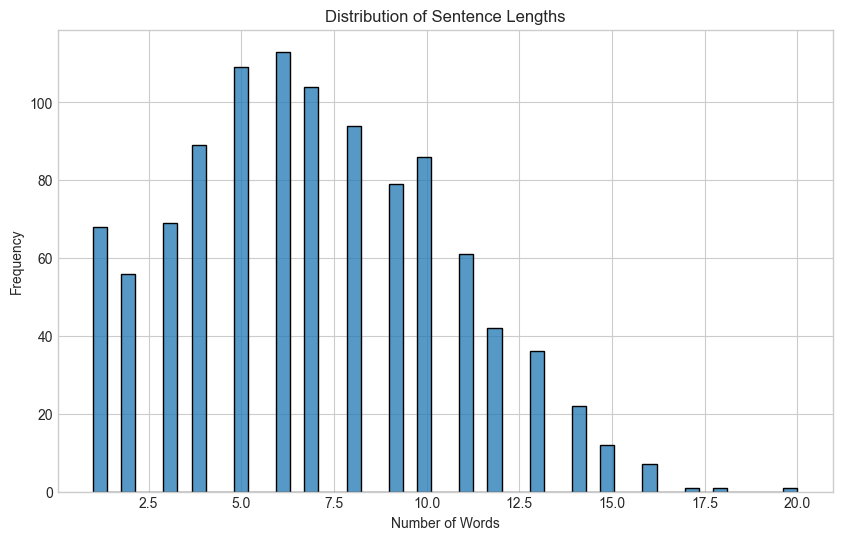

In [15]:
# Visualize sentence length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Sentence_length'], bins=50)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

### 2. Speaker Distributions

1. **Speaker Distribution**  
   - The code retrieves the frequency of each unique speaker using `value_counts()`.  
   - The Top 10 speakers with the most utterances are printed in the console for quick inspection.  

2. **Visualization**  
   - A bar chart is created showing the Top 20 speakers by number of utterances.  
   - The plot is styled with a white grid (`seaborn-v0_8-whitegrid`) for readability.  
   - Labels and titles are added for clarity, and the x-axis labels (speaker IDs) are rotated for better visibility.  

3. **Error Handling**  
   - If the dataset does not contain a `Speaker` column, a clear message is printed instead of raising an error.  


In [16]:
# --- Speaker and Show Distributions ---
print("\n--- Speaker and Show Distributions ---")
plt.style.use('seaborn-v0_8-whitegrid')
try:
    # Speaker distribution
    speaker_counts = df['Speaker'].value_counts()
    print(f"\nTop 10 speakers:\n{speaker_counts.head(10)}")

    plt.figure(figsize=(12, 6))
    speaker_counts.head(20).plot(kind='bar')
    plt.title('Top 20 Speaker Distribution')
    plt.xlabel('Speaker ID')
    plt.ylabel('Number of Utterances')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
except KeyError:
    print("Column 'Speaker' not found in the dataset.")

# the data provided by the client did not include speaker detection however our own data does provide this so we did include it in hour evaluation
# but depending on the data that is passed through this you might not get a visualization


--- Speaker and Show Distributions ---
Column 'Speaker' not found in the dataset.



### 3. Emotion Distribution and Coverage

1. **Mapping Sentiment Labels**  
   - The dataset contains numerical sentiment predictions (`Predicted_sentiment`) coded as:  
     - `0 → Negative`  
     - `1 → Neutral`  
     - `2 → Positive`  
   - A new column `Sentiment_label` is created by mapping these integers to human-readable labels.

2. **Emotion Counts**  
   - The frequency of each sentiment category is computed using `value_counts()`.  
   - The counts are printed to provide a quick overview of how many examples belong to each class.

3. **Visualization**  
   - A bar plot is created with Seaborn to show the distribution of emotions.  
   - The x-axis represents the sentiment categories (`Negative`, `Neutral`, `Positive`), and the y-axis shows their frequencies.  
   - Labels and titles are added for clarity, with rotated x-ticks for better readability.


--- Emotion Distribution & Coverage ---
Emotion counts:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


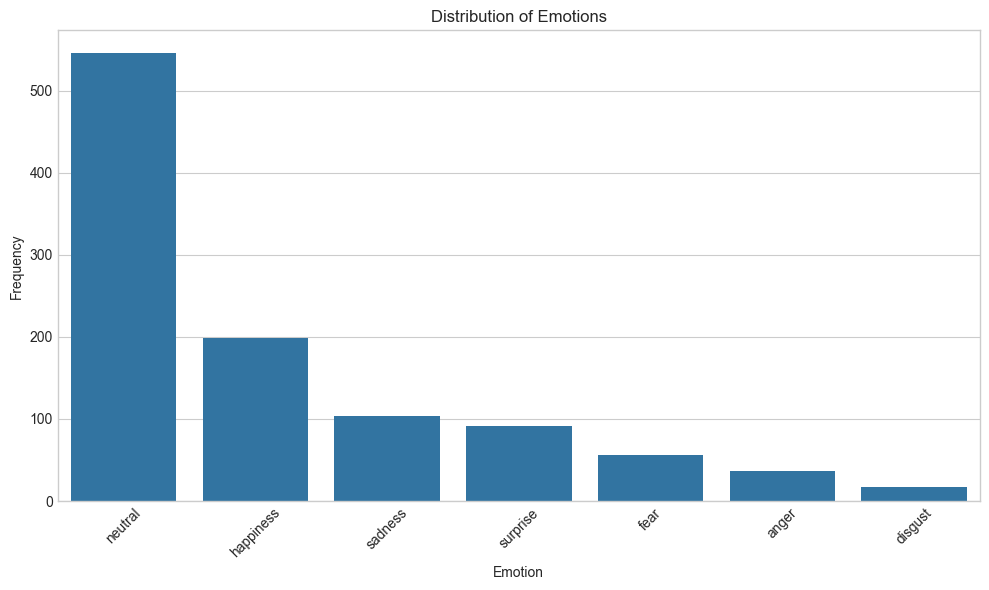

In [17]:
# --- Emotion Distribution & Coverage ---
print("\n--- Emotion Distribution & Coverage ---")


# Map numerical values to sentiment labels
emotion_counts = df['Emotion_core'].value_counts()
print(f"Emotion counts:\n{emotion_counts}")

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
try:
    df['Intensity'].unique()
except KeyError:
    df['Intensity'] = None

Here, we examine the intensity of the emotions present. This analysis can provide insights into the overall level of the conversation. High intensity may indicate the presence of strong emotions such as happiness and anger. This information could be a valuable output for our client in certain types of analyses.


--- Fine emotion Distribution & Coverage ---
Emotion counts:
Intensity
mild        546
neutral     382
moderate    108
intense      14
Name: count, dtype: int64


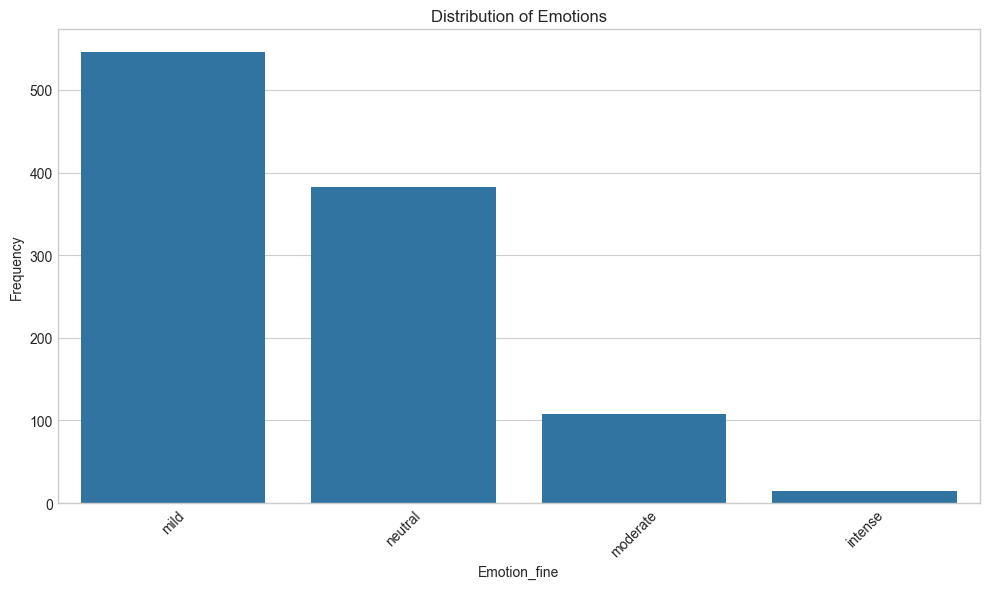

In [19]:
print("\n--- Fine emotion Distribution & Coverage ---")


# Map numerical values to sentiment labels
emotion_counts = df['Intensity'].value_counts()
print(f"Emotion counts:\n{emotion_counts}")

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Distribution of Emotions')
plt.xlabel('Emotion_fine')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Identifying Whether Certain Emotions Are Underrepresented

There are some emotions that are severely underrepresented:

Disgust: 17 instances (1.6%) – Critically low
Anger: 37 instances (3.5%) – Very underrepresented
Fear: 56 instances (5.4%) – Notably low

Moderately underrepresented:

Surprise: 92 instances (8.8%) – Below expected levels

#### Key Issues

Class imbalance problem: the dataset is heavily skewed toward neutral (52%), with negative emotions severely lacking. The reason for this is that the type of video we provided contained a large proportion of neutral emotions. In most conversations, the context will be mainly neutral. There are, of course, exceptions such as sports events or funerals.

Using this dataset as training data presents several issues, such as poor model performance on underrepresented classes, inability to detect anger, disgust, or fear effectively, and biased predictions toward neutral/happiness.

#### Impact on Analysis

Any machine learning model trained on this data will struggle to identify anger, disgust, or fear.
The model will likely misclassify these emotions as neutral or other categories.
Statistical analysis of emotional patterns will be unreliable for rare emotions. If we pass data that contains a significant amount of disgust, the model’s performance could become unusable because of the poor data quality.

#### Future Steps

We could collect more data specifically targeting underrepresented emotions.
Use data augmentation techniques for rare classes.
Consider emotion grouping, for example, combining anger/disgust as "negative arousal."
Apply class weighting in models to compensate for imbalance.
Use stratified sampling when splitting train/test sets.

We need to keep this in mind while collecting more data in the future to train the model. Our focus should be on obtaining higher-quality and less skewed data.

### 4. Domain Characteristics
Here, we examine the linguistic patterns characteristic of spoken television. A qualitative analysis is conducted on a sample of the data, focusing on the identification and relevance of key linguistic patterns. What is relevant for our use case are concepts that give us insight about how the speech is used to communicate and what characteristics it has Such as:
<!-- - Phonetics and phonology: Phonetics is the study of sounds of language, while phonology is the study of the smallest distinctive sounds of a language that can distinguish meaning. -->
<!-- - Allophones: Which is a context bound variant of a phonemes. It is an adaptation of a phonemes based on their surrounding sounds which becomes evident in dialects and can signal identity. -->
<!-- - Morphology: Refers to examining the inflectional and derivational processes of words. These are word formation processes, such as adding suffixes to change the meaning or part of speech catagory. -->
- Syntax: Studies the arrangement of words and phrases to create sentences. Using syntax trees we can retrieve sentence structures and see how each word relates to the other. This helps us and Emotion classification models to disambiguate sentence meaning and track what modifier words such as quantifiers and adjectives .
- Sementics: Studies the meaning at lexical, sentential and discourse levels.
    <!-- - Lexical semantics (word-level): Refers to the study of how words relate to each other. Examples of this are synonyms antonyms, polysems, homonyms and hyponyms. -->
    - Sentential semantics (sentence-level): Looks to examine how the meanings of words combine to form a sentence meaning. This is often achieved by using formal semantics which applies tools from logic to represent the meaning of a sentence precisely. Some examples of these tools are:
        - Compositionality: The meaning of the sentence is built from its parts and structure
        - Quantification: Words like all, some, every and no effect meaning
        - Scope ambiguity: When multiple quantifiers interact the sentence can have multiple meanings. 
    <!-- - Discourse semantics (paragraph/conversation-level): Studies the meaning in exteded texts or conversations, this deals with things like references and cohesion, presuppositions, implicature and thematic structure. -->

We also extract the frequency of common spoken language features such as fillers (e.g., “um,” “uh”), hesitations, slang, and contractions.

### Classification Logic Explained

The core of the classification relies on these three key features, which act as indicators of sentence complexity:

 **`independent_clauses_count`**: This variable counts the number of potential independent clauses. It's a proxy, or shortcut, that assumes each verb with its own subject (`nsubj` dependency) represents a new clause. A sentence with two or more independent clauses will be either compound or compound-complex.
 **`has_coord_conj`**: This boolean flag checks for the presence of a coordinating conjunction (POS tag `CCONJ`), such as 'en' (and) or 'maar' (but). Coordinating conjunctions are used to join two or more independent clauses.
 **`has_subord_elem`**: This boolean flag checks for subordinating elements, which include subordinating conjunctions (POS tag `SCONJ`) like 'omdat' (because) and relative clauses (`relcl` dependency). These elements introduce dependent clauses, which cannot stand alone as a complete sentence.

Based on these features, the code applies a hierarchy of `if/elif/else` statements to classify the sentences:

1.  Compound-Complex Sentence: The most complex type is checked for first. A sentence is classified as compound-complex if it has more than one independent clause(`independent_clauses_count > 1`) and contains both a coordinating conjunction and a subordinating element. This is the only type that contains all three features.

2.  Compound Sentence: If the sentence isn't compound-complex, the code checks if it's a compound sentence. This is true if it has more than one independent clause and at least one coordinating conjunction. This distinguishes it from a simple sentence, which only has one clause.

3.  Complex Sentence: If the first two conditions are not met, the code checks for a complex sentence. A sentence is classified as complex if it contains any subordinating element, regardless of the number of independent clauses. This rule works because a dependent clause is the defining feature of a complex sentence.

4.  Simple Sentence: If none of the above conditions are met, the sentence is classified as simple. This acts as the default case, correctly identifying sentences that have only one independent clause and no subordinating elements.

This logical flow ensures that each sentence is categorized into the most complex type it qualifies for.

In [20]:
from collections import defaultdict

def count_and_example_sentence_types(df, text_column='Sentence'):
    """
    Analyzes, counts, and prints examples of simple, compound, complex,
    and compound-complex sentences in a DataFrame column.
    """
    nlp = spacy.load("nl_core_news_lg")
    
    sentence_counts = {
        'simple': 0,
        'compound': 0,
        'complex': 0,
        'compound-complex': 0
    }
    
    examples = defaultdict(list)

    for sentence in df[text_column]:
        doc = nlp(sentence)
        
        has_coord_conj = any(token.pos_ == "CCONJ" for token in doc)
        has_subord_elem = any(token.pos_ == "SCONJ" or token.dep_ == "relcl" for token in doc)
        
        independent_clauses_count = 0
        for token in doc:
            if token.pos_ == "VERB" and any(child.dep_ == "nsubj" for child in token.children):
                independent_clauses_count += 1
        
        # Classification Logic
        if independent_clauses_count > 1 and has_coord_conj and has_subord_elem:
            sentence_type = 'compound-complex'
        elif independent_clauses_count > 1 and has_coord_conj:
            sentence_type = 'compound'
        elif has_subord_elem:
            sentence_type = 'complex'
        else:
            sentence_type = 'simple'

        sentence_counts[sentence_type] += 1
        
        if len(examples[sentence_type]) < 3:
            examples[sentence_type].append(sentence)
            
    # Print the results
    print("--- Sentence Structure Counts ---")
    for structure, count in sentence_counts.items():
        print(f"{structure.capitalize()}: {count}")

    print("\n--- Example Sentences ---")
    for structure, example_list in examples.items():
        print(f"\n{structure.capitalize()} Sentences:")
        for example in example_list:
            print(f"- {example}")

# Run the function on the DataFrame
print("\n--- Wie is de mol ---")
count_and_example_sentence_types(df)
print("\n--- Training data ---")
df_train = pd.read_csv("..\\data\\dataset\\processed\\go_emotion_dutch.csv")
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_train = df_train.iloc[:1050]  # Ensure we only take the first 1050 rows
count_and_example_sentence_types(df_train)


--- Wie is de mol ---
--- Sentence Structure Counts ---
Simple: 875
Compound: 28
Complex: 139
Compound-complex: 8

--- Example Sentences ---

Simple Sentences:
- TV GELDERLAND 2021.
- Daar boven staat een kist.
- O, kwaak!

Complex Sentences:
- Ik weet zeker dat ik ze alle vier gehad heb.
- dat het verse gezinsgeluk kan verstoren.
- dat juist politievrouw Ellie na een glorieuze klimpartij...

Compound Sentences:
- Ik wil het volhouden, want ik zou het helemaal te gek vinden.
- En er liep een pad langs het strand waar je lekker kon wandelen.
- En aan sommige hangt het juiste antwoord op een vraag die ik ga stellen.

Compound-complex Sentences:
- Maar we zagen ook dat er zeven fietsen stonden.
- En die vertelde ons dat we moesten gaan fietsen.
- En ik merk wel wanneer de eerste envelop komt.

--- Training data ---
--- Sentence Structure Counts ---
Simple: 592
Compound: 59
Complex: 302
Compound-complex: 97

--- Example Sentences ---

Simple Sentences:
- Je hebt gelijk, dat ben ik ook teg

### Conclusion
Based on the results we can see that the training data has longer sentences, indicating that the sentence splitting of the two dataset is not the same. Adding preprocessing of the training set so each row contains its own sentence is a good future direction to improve our dataset

In [21]:
import pandas as pd
import re
from collections import defaultdict


def analyze_corpus_characteristics(df, text_column='Sentence', emotion_column=None):
    """
    Analyzes and prints linguistic characteristics of a corpus, including counts
    of specific word types and examples.

    Args:
        df (pd.DataFrame): The input DataFrame.
        text_column (str): The name of the column containing the text data.
        emotion_column (str, optional): The name of the column containing emotion/sentiment.
                                        If provided, a sample will be printed.
    """

    # --- Pre-defined Dictionaries ---
    dutch_fillers = {
        "uh": "common hesitation", "um": "common hesitation", "eh": "short hesitation",
        "nou": "well/so", "zeg maar": "you know / like", "weet je": "you know",
        "dus": "so", "eigenlijk": "actually", "gewoon": "just/simply",
        "toch": "right?", "hè": "eh?", "uhm": "hesitation",
        "kijk": "look/see", "immers": "after all/for", "wel": "well/surely",
        "oké": "okay", "ehm": "hesitation", "en": "and"
    }

    dutch_swear_words = [
        "kut", "godverdomme", "tering", "klote", "verdomme", "stom", "shit",
        "klootzak", "zak", "lul", "sodemieter", "donder op", "hoer", "kanker",
        "tyfus", "teringzooi", "rot op", "jezus", "godnondeju", "eikel", "sukkel",
        "achterlijk", "zeikerd", "etter", "stinkerd", "klerelijer", "mongool", "de tering"
    ]

    dutch_colloquial_expressions = [
        "joh", "hè hè", "goh", "tjonge jonge", "potverdorie", "doodgewoon",
        "nou en", "toe maar", "echt waar", "lekker puh", "ach ja", "zo zo",
    ]

    dutch_spoken_connectors = [
        "trouwens", "immers", "namelijk", "althans", "bijvoorbeeld", "kortom", "zowel",
        "overigens", "daarom", "echter", "integendeel", "daardoor", "vooral", "kortom"
    ]

    dutch_diminutives = ["tje", "je", "pje", "kje", "etje"]

    dutch_casual_greetings = [
        "hoi", "hallo", "dag", "doei", "later", "ciao", "tot ziens",
        "goedemorgen", "goedemiddag", "goedenavond", "slaap lekker", "tot straks", "ciao", "hallo"
    ]

    dutch_quantifiers = [
        "alle", "veel", "meeste", "weinig", "enkele", "sommige", "genoeg", "meer", "minder",
        "iedere", "elk", "geen", "allemaal", "beide", "talloze", "diverse", "menig", "meerdere",
        "enkel", "zoveel"
    ]
    dutch_short_words_with_punctuation = {
            "z'n": "zijn",
            "zo'n":"zo een",
            "d'r": "haar",
            "'k": "ik",
            "'t": "het",
            "'m": "hem",
            "'n": "een",
            "'r": "haar",
            "m'n": "mijn",
            "z'n'n": "zijn een",
            "m'n'n": "mijn een",
            "'n": "een",
            "'t": "het",
            "'k": "ik",
            "'ns": "eens",
            "'es": "eens",
            "'is": "eens",
            "'ie": "hij",
            "'em": "hem",
            "'twas": "het was"
        }
    # --- Domain Characteristics (Optional) ---
    print("--- Domain Characteristics ---")
    if emotion_column and emotion_column in df.columns:
        print("Random sample of transcriptions and sentiment:")
        sample_data = df.sample(n=min(5, len(df)), random_state=42)
        for index, row in sample_data.iterrows():
            print(f"Transcription: {row[text_column]}\nEmotion: {row[emotion_column]}\n---")
    else:
        print("Random sample of transcriptions:")
        sample_data = df.sample(n=min(5, len(df)), random_state=42)
        for index, row in sample_data.iterrows():
            print(f"Transcription: {row[text_column]}\n---")

    # --- Regex Patterns ---
    patterns = {
        'fillers': dutch_fillers.keys(),
        'swear_words': dutch_swear_words,
        'colloquial_expressions': dutch_colloquial_expressions,
        'spoken_connectors': dutch_spoken_connectors,
        'diminutives': dutch_diminutives,
        'casual_greetings': dutch_casual_greetings,
        'quantifiers': dutch_quantifiers
    }

    # Contractions: don't use \b (apostrophes break it)
    contraction_pattern = r'(?:' + '|'.join(map(re.escape, sorted(dutch_short_words_with_punctuation.keys(), key=len, reverse=True))) + r')'

    # --- Count occurrences and store examples ---
    total_counts = defaultdict(int)
    examples = defaultdict(list)
    
    for _, row in df.iterrows():
        sentence = str(row[text_column]).lower()
        
        # Count contractions
        contraction_count = len(re.findall(contraction_pattern, sentence, flags=re.IGNORECASE))
        total_counts['contraction'] += contraction_count
        if contraction_count > 0 and len(examples['contraction']) < 3:
            examples['contraction'].append(row[text_column])

        # Count other patterns
        for name, items in patterns.items():
            sorted_items = sorted(items, key=len, reverse=True)
            if name == 'diminutives':
                # Diminutive pattern needs a word boundary at the start, not the end
                regex = r'\b\w+(?:' + '|'.join(map(re.escape, sorted_items)) + r')\b'
            else:
                regex = r'\b(?:' + '|'.join(map(re.escape, sorted_items)) + r')\b'

            count = len(re.findall(regex, sentence, flags=re.IGNORECASE))
            total_counts[name] += count
            if count > 0 and len(examples[name]) < 3:
                examples[name].append(row[text_column])

    # --- Print Totals ---
    print("\n--- Total Occurrences ---")
    print(f"Total occurrences of Dutch filler words: {total_counts['fillers']}")
    print(f"Total occurrences of Dutch contractions: {total_counts['contraction']}")
    print(f"Total occurrences of Dutch swear words: {total_counts['swear_words']}")
    print(f"Total occurrences of Dutch colloquial expressions: {total_counts['colloquial_expressions']}")
    print(f"Total occurrences of Dutch spoken connectors: {total_counts['spoken_connectors']}")
    print(f"Total occurrences of Dutch diminutives: {total_counts['diminutives']}")
    print(f"Total occurrences of Dutch casual greetings: {total_counts['casual_greetings']}")
    print(f"Total occurrences of Dutch quantifiers: {total_counts['quantifiers']}")

    # --- Print Examples ---
    print("\n--- Example Sentences by Category ---")
    for name, example_list in examples.items():
        title = name.replace('_', ' ').capitalize()
        print(f"\n- {title}:")
        for example in example_list:
            print(f"  - {example}")

print("\n--- Wie is de mol ---")
analyze_corpus_characteristics(df, text_column='Sentence', emotion_column='Emotion_core')
print("\n--- Training data ---")
analyze_corpus_characteristics(df_train.head(1050), text_column='Sentence', emotion_column='Emotion_core')



--- Wie is de mol ---
--- Domain Characteristics ---
Random sample of transcriptions and sentiment:
Transcription: Het leek een simpele opdracht.
Emotion: neutral
---
Transcription: Succes!
Emotion: happiness
---
Transcription: Prachtig kalm water, prachtige mangroves.
Emotion: happiness
---
Transcription: Dus die heeft eigenlijk ons verbondje weer aangemaakt.
Emotion: happiness
---
Transcription: De groep wordt kleiner.
Emotion: sadness
---

--- Total Occurrences ---
Total occurrences of Dutch filler words: 329
Total occurrences of Dutch contractions: 9
Total occurrences of Dutch swear words: 8
Total occurrences of Dutch colloquial expressions: 0
Total occurrences of Dutch spoken connectors: 15
Total occurrences of Dutch diminutives: 53
Total occurrences of Dutch casual greetings: 13
Total occurrences of Dutch quantifiers: 69

--- Example Sentences by Category ---

- Quantifiers:
  - Ik weet zeker dat ik ze alle vier gehad heb.
  - Bij iedere afvaller die vertrekt, valt het afscheid 

### Conclusion
The distribution of the total occurrences of each type of word is similar, there are less swear words in our content which makes sense since its a tv show

### Transcription Artifacts Analysis
Transcription artifacts are technical errors that occur when converting spoken television dialogue into text. These errors provide evidence that our dataset is derived from real speech rather than written material.

Encoding errors (e.g., â€™ instead of an apostrophe) indicate file format corruption. Timestamps (e.g., [12:34]) are residual markers from the original transcription process. Speaker labels (e.g., A: or SPEAKER 1:) reflect the multi-speaker dialogue structure. Transcription notes (e.g., [inaudible], coughs) highlight moments where the audio was unclear. Repeated sequences (e.g., aaaaa) typically result from software glitches. Numerical confusions (e.g., 1 instead of “een”) are common speech recognition errors.

These artifacts not only confirm the dataset’s origin in authentic spoken language but also underscore potential data quality issues that must be considered during analysis.

In [22]:
def count_transcription_artifacts(df):
    """Count transcription artifacts in the Sentence column"""
    
    artifacts = {
        'encoding_errors': r'â€™|â€œ|â€\x9d',
        'timestamps': r'\d{1,2}:\d{2}:\d{2}|\[\d+:\d+\]|\(\d+:\d+\)',
        'speaker_labels': r'^[A-Z]+:|^\w+\s*:',
        'transcription_marks': r'\[inaudible\]|\[unclear\]|\*\w+\*|\[.*?\]',
        'repeated_errors': r'(.)\1{4,}',
        'number_confusions': r'\b1\b(?=\s+[a-z])'
    }
    
    results = {}
    for artifact_type, pattern in artifacts.items():
        count = 0
        for sentence in df['Sentence']:
            if re.search(pattern, str(sentence)):
                count += 1
        results[artifact_type] = count
    
    # Print results
    print("TRANSCRIPTION ARTIFACTS FOUND:")
    total_artifacts = 0
    for artifact_type, count in results.items():
        print(f"{artifact_type}: {count}")
        total_artifacts += count
    
    print(f"\nTotal sentences with artifacts: {total_artifacts}")
    print(f"Percentage: {total_artifacts/len(df)*100:.1f}%")

# Run on your dataset
count_transcription_artifacts(df)

TRANSCRIPTION ARTIFACTS FOUND:
encoding_errors: 0
timestamps: 0
speaker_labels: 0
transcription_marks: 0
repeated_errors: 0
number_confusions: 4

Total sentences with artifacts: 4
Percentage: 0.4%


## Data Quality Check

I used this code to check 15 instances for each emotion and manually review the output. I did this to identify which emotions the model struggled with and to determine whether there were many spelling mistakes. This also allowed me to examine whether there were any words that the model consistently misclassified.

In [23]:
pd.set_option('display.max_colwidth', None)
emotion_sentences = df[df['Emotion_core'] == 'surprise']['Sentence']
print(emotion_sentences.sample(15))

537                                                      Andersom.
11                   Want de openheid is ingeruild voor mysteries.
997                                                           Oeh!
655       Het is heel onwerkelijk om hier met z'n allen te zitten.
558              Dat is een 8. Staat er nog iets op de achterkant?
815                                            Waar zeg je zevera?
609                                 O, dit is hem. Dit is de Boca.
15                    Al leek Marjolein vooral perplex te staan...
415    Jullie gaan straks per boot op zoek naar deze negen tekens.
657                                       Klaas. Ik schrik het in.
518          Oké, dan gaan we jullie... Hoe zien die boeien eruit?
538                                                  Andersom, hè?
607                                                 Tof! Is dit...
656        We zitten ook op een soort filmlocatie, lijkt wel soms.
353           Toen bleek dat de nummers ook nog volgorde hinge

In [24]:
right_anger = 14
wrong_anger = 1

right_neutral = 15
wrong_neutral = 0

right_disgust = 8
wrong_disgust = 7

right_hapiness = 15
wrong_hapiness = 0

right_surprise = 11
wrong_surprise = 4

right_fear = 10
wrong_fear = 5

misspelling = 10
correctly_spelled = 80 

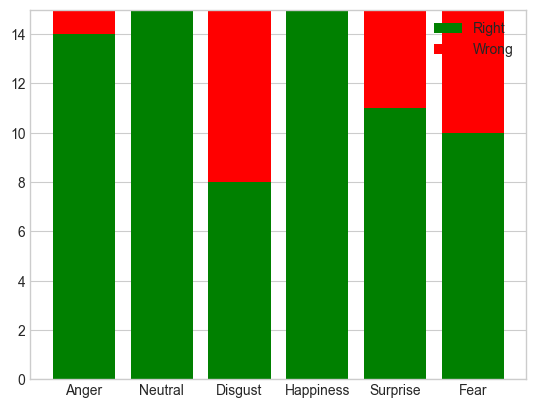

In [25]:
emotions = ['Anger', 'Neutral', 'Disgust', 'Happiness', 'Surprise', 'Fear']
right = [14, 15, 8, 15, 11, 10]
wrong = [1, 0, 7, 0, 4, 5]

# Simple bar chart
plt.bar(emotions, right, label='Right', color='green')
plt.bar(emotions, wrong, bottom=right, label='Wrong', color='red')
plt.legend()
plt.show()

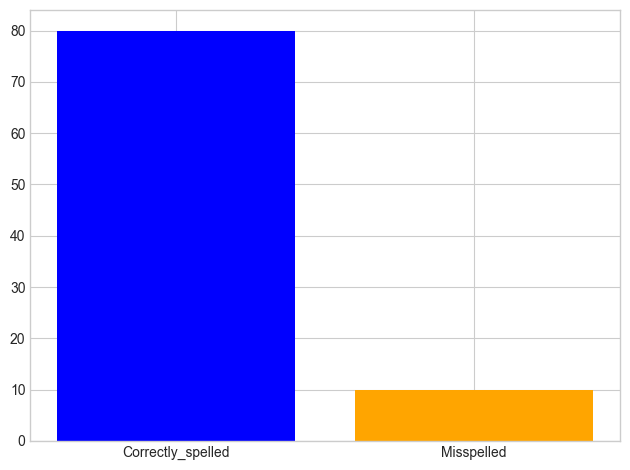

In [26]:
plt.bar(['Correctly_spelled', 'Misspelled'], [80, 10], color=['blue', 'orange'])

plt.tight_layout()
plt.show()


#### Insights
The insights i gained from this analysis is that the model captures emotions that are well represented(neutral, happiness, anger) a lot better than emotions that are under represented(disgust, surprise, fear). This could be because the model was trained on a skewed dataset. Real world data often contains little disgust, surprise or fear. This is depended on the context. Another valuable insight i gained was that the model would draw conclusions based on certain dutch sayings. Things like 'Mosterd after dinner" it labeled as disgust. But this does not have to be true. The spelling accuracy was good. but not as good as our current assemblyAI model. I also witnessed no encoding errors. Other than the dutch sayings we found no other encoding errors

## Reflection for Training Data Selection



Based on my findings from analyzing the emotion distribution and domain characteristics, I need to gather training data that addresses several critical gaps in the current dataset. The most pressing issue is the severe emotional imbalance where negative emotions like disgust represent only 1.6% of the data, anger 3.5%, and fear 5.4%. This skewed distribution toward neutral emotions at 52% creates a model that struggles with real-world emotional detection.

To cover the domain properly, I need to collect data from diverse television genres beyond the current reality show format. This means including dramatic series, news programs, sports commentary, talk shows, and competitive reality shows where emotional intensity naturally runs higher. The current dataset shows very low informal language usage at only 3.5%, which suggests the content may be too polished or edited compared to authentic spontaneous speech.

For emotional balance, I need to target content that naturally contains more negative emotions. Sports events during crucial moments, debate programs, dramatic television, and reality show elimination episodes would provide the anger, fear, and disgust examples currently missing. I should aim for at least 20-30% negative emotions rather than the current 10% to create a model that can reliably detect these important emotional states.

The analysis revealed that high-intensity emotions represent only 1.3% of the dataset, which is problematic since intense emotions are often the most important to detect. I need to specifically seek out content with passionate discussions, competitive moments, shocking revelations, and high-stakes situations to balance this distribution.

Additionally, I need to address the Dutch-specific linguistic challenges where cultural expressions and idioms confuse the model. This requires more careful annotation and possibly separate handling of idiomatic expressions during preprocessing. The current transcription quality shows 10% spelling errors, so I should focus on higher quality source material or implement better Dutch language preprocessing.
To achieve proper coverage, the training data should include speakers of different ages, regional accents, speaking speeds, and emotional expressiveness. The current data appears to come from a controlled television environment, but real-world application requires more variety in speaking styles and contexts.